- 실습 기본 환경 설정

In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 9-1 Seq2Seq 모델

본 노트북은 9-1절 본문 예제 [코드 9-1]~[코드 9-12]를 모아 위에서 아래로 실행해 본다.

다루는 내용
- 입력/출력 어휘 사전과 데이터셋 정의 ([코드 9-1], [코드 9-2])
- 배치 크기 1 데이터로더 ([코드 9-3])
- Seq2Seq 인코더/디코더와 DateConverter 클래스 ([코드 9-4]~[코드 9-9])
- 모델 객체 생성과 학습 함수 ([코드 9-10], [코드 9-11])
- 검증 함수와 학습 루프 (본문 미공개, 노트북에서 정의)
- 학습된 모델로 날짜 문자열 생성 ([코드 9-12])

데이터셋 생성 함수 `generate_datepairs`, `choice_random_dates`는 워크스페이스
`data/data.ipynb`의 본문을 그대로 가져와 노트북 안에서 재정의해 사용한다.

이번 절은 본문의 모델 12의 구현을 포함한다. 모델 12의 제시문은 다음과 같다.

> **모델 12. 날짜 형식 변환기 모델**
>
> 영문으로 날짜를 적는 방법은 다양하다. 2026년 2월 1일을 표현하는 여덟 가지 형식은 다음과 같다.
>
> - `01 February 2026` 또는 `01 Feb 2026`
> - `February 01, 2026` 또는 `Feb 01, 2026`
> - `02/01/2026` 또는 `2026/02/01`
> - `01-02-2026` 또는 `2026-02-01`
>
> 1900년 1월 1일부터 2050년 12월 31일 사이의 어떤 날짜를 위 형식 중 하나로 입력하면 연-월-일의 형식(예: 2026-2-1)으로 변환하는 날짜 형식 변환기 모델을 만들어 보자. 입력 날짜 문자열은 월과 일이 한 자리이면 0으로 채워 두 자리로 맞추지만, 출력 문자열은 한 자리를 그대로 둔다.

## 날짜 데이터 생성 (data.ipynb 본문)

본문 [코드 9-1] 직전에 사용하는 `src_dates`/`tgt_dates`는 데이터 생성 함수
두 개의 결과다. 함수 본문은 `data/data.ipynb`에 정의되어 있으며, 재현성과
독립 실행을 위해 노트북에 그대로 옮겨 사용한다.

In [ ]:
# 참고 - 데이터 생성 함수
from datetime import datetime, timedelta
import random

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# datetime 리스트를 입력 리스트와 정답 리스트로 변환하는 함수
# 입력은 src_formats에 정의된 형식으로, 정답은 'YYYY-M-D' 형식으로 변환
def generate_datepairs(date_list, src_formats=src_formats):
    if len(src_formats) == 0:
        raise ValueError('입력 문자열 템플릿이 비어 있습니다.')
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(date.strftime(src_format))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


# 4,000개의 (입력, 정답) 날짜 쌍 생성
date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_datepairs(date_list)
print(f'생성된 날짜 쌍의 수: {len(src_dates)}')

# 입력 -> 정답 예시(5건)
print('데이터 예시(5건)')
print('    입력 날짜 문자열     -> 정답 날짜 문자열')
for i in range(min(5, len(src_dates))):
    print(f'    {src_dates[i]:<20s} -> {tgt_dates[i]}')

생성된 날짜 쌍의 수: 4000
데이터 예시(5건)
    입력 날짜 문자열     -> 정답 날짜 문자열
    25 September 2014    -> 2014-9-25
    24 Dec 1919          -> 1919-12-24
    June 28, 1904        -> 1904-6-28
    Jan 21, 2033         -> 2033-1-21
    05/08/1949           -> 1949-5-8


## [코드 9-1] 입력과 출력 어휘 사전 생성

글자 단위 토큰에 특수 토큰을 더한 어휘 사전을 클래스로 정의한다. 입력과
출력에 사용하는 토큰 구성이 다르므로 어휘 사전도 입력(`src_vocab`)과
출력(`tgt_vocab`)을 따로 만든다.

In [3]:
########################################################################################
# 코드 9-1 - 클래스를 정의해 만든 입력과 출력 어휘 사전
########################################################################################
# 특수 토큰과 특수 토큰 딕셔너리
SOS_TOKEN, EOS_TOKEN = '<sos>', '<eos>'
SOS_IDX, EOS_IDX = 0, 1
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX}

# 어휘 사전 클래스: 글자 단위 토큰에 특수 토큰을 더한 어휘 사전
class Vocab:
    def __init__(self, sequence_list, special_tokens):
        # 고유한 토큰의 집합(set)
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        # 어휘 사전: {토큰: 고유 번호} 형태의 딕셔너리
        self.vocab = {}
        # 특수 토큰을 어휘 사전에 먼저 추가
        self.vocab.update(special_tokens)
        idx_start = len(special_tokens)
        # 정렬한 토큰을 고유 번호와 함께 어휘 사전에 추가
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        # 역방향 어휘 사전: {고유 번호: 토큰} 형태의 딕셔너리
        self.itos = {idx: token for token, idx in self.vocab.items()}

    # 인코딩: 문자열 -> 고유 번호 리스트
    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    # 디코딩: 고유 번호 리스트 -> 토큰 리스트
    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    # 어휘 사전의 크기(고유한 토큰의 수)를 반환
    def __len__(self):
        return len(self.vocab)


src_vocab = Vocab(src_dates, special_tokens)        # src: source(입력)의 축약
tgt_vocab = Vocab(tgt_dates, special_tokens)        # tgt: target(정답)의 축약

print(f'입력 어휘 사전 크기: {len(src_vocab)}')
print(f'정답 어휘 사전 크기: {len(tgt_vocab)}')

입력 어휘 사전 크기: 42
정답 어휘 사전 크기: 13


## [코드 9-2] Seq2Seq 모델 학습용 데이터셋 생성

데이터셋은 정답 순차 데이터의 앞뒤에 `<sos>`, `<eos>`를 덧붙여 구성한다.
디코더 입력에는 `[..., :-1]` 슬라이싱으로 `<eos>`를 제외하고, 손실 함수
정답에는 `[..., 1:]` 슬라이싱으로 `<sos>`를 제외해 사용한다.

In [4]:
########################################################################################
# 코드 9-2 - Seq2Seq 모델 학습용 데이터 준비
########################################################################################
import torch
from torch.utils.data import Dataset, DataLoader

# 날짜 변환기 모델 학습용 데이터셋 클래스
#    src_dates, src_vocab: 입력 날짜 문자열과 입력 어휘 사전
#    tgt_dates, tgt_vocab: 정답 날짜 문자열과 정답 어휘 사전
class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = []
        for src_date, tgt_date in zip(src_dates, tgt_dates):
            src_ids = src_vocab.encode(src_date)
            tgt_ids = tgt_vocab.encode(tgt_date)
            # 정답 순차 데이터의 앞뒤에 <sos>, <eos> 추가
            #    디코더 입력: [..., :-1] 슬라이싱으로 <eos>를 제거하고 사용
            #    손실 함수 입력: [..., 1:] 슬라이싱으로 <sos>를 제거하고 사용
            tgt_ids = [SOS_IDX] + tgt_ids + [EOS_IDX]
            self.samples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src_ids, tgt_ids = self.samples[idx]
        # 고유번호의 리스트를 long형 텐서로 변환해 반환
        src = torch.tensor(src_ids, dtype=torch.long)
        tgt = torch.tensor(tgt_ids, dtype=torch.long)
        return src, tgt


# 샘플 수가 각각 3,000개, 1,000개인 훈련 데이터셋과 검증 데이터셋 생성
#   : 입력과 정답 순차 데이터가 같은 순서로 짝지워져 있어 순서대로 분리해 사용
train_set = DateDataset(src_dates[:3000], tgt_dates[:3000], src_vocab, tgt_vocab)
valid_set = DateDataset(src_dates[3000:], tgt_dates[3000:], src_vocab, tgt_vocab)

print(f'훈련 데이터셋 크기: {len(train_set)}')
print(f'검증 데이터셋 크기: {len(valid_set)}')

# 정답 샘플 텐서의 첫 토큰과 마지막 토큰
tgt_sample = train_set[0][1]
print('정답 샘플 텐서의 첫 토큰:', tgt_sample[0].item())        # <sos> 토큰
print('정답 샘플 텐서의 마지막 토큰:', tgt_sample[-1].item())   # <eos> 토큰

# 배치 크기 1인 데이터로더 생성: 배치 학습하지 않고 샘플 별로 반복 학습
BATCH_SIZE = 1
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'배치 크기: {BATCH_SIZE}')
print(f'훈련 데이터로더 배치 수: {len(train_loader)}')
print(f'검증 데이터로더 배치 수: {len(valid_loader)}')

훈련 데이터셋 크기: 3000
검증 데이터셋 크기: 1000
정답 샘플 텐서의 첫 토큰: 0
정답 샘플 텐서의 마지막 토큰: 1
배치 크기: 1
훈련 데이터로더 배치 수: 3000
검증 데이터로더 배치 수: 1000


## [코드 9-3] 배치 크기를 1로 지정해 데이터로더 생성

가변 길이 패딩을 9-2절로 미루기 위해, 이번 절에서는 배치 크기를 1로 두어
샘플마다 형태가 달라지는 문제를 잠시 피해 간다.

## [코드 9-4] Seq2Seq 모델의 인코더 클래스

인코더는 임베딩 계층과 LSTM 계층으로 구성된다. `forward()`는 LSTM 계층의
두 번째 반환값 `(hidden, cell)`을 언패킹해 둘 다 반환한다.

- `hidden`: 모든 층의 마지막 숨겨진 상태(단기 기억), `(num_layers, B, hidden_dim)`
- `cell`: 모든 층의 마지막 셀 상태(장기 기억), `(num_layers, B, hidden_dim)`

In [5]:
########################################################################################
# 코드 9-3 - Seq2Seq 모델의 인코더 클래스
########################################################################################
import torch.nn as nn

# 콘텍스트 벡터를 생성하는 인코더(임베딩 계층 -> LSTM 계층으로 구성)
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        # 임베딩 계층
        self.encoder_embedding = nn.Embedding(src_vocab_size, embed_dim)
        # 순환 신경망(LSTM) 계층
        self.encoder_lstm = nn.LSTM(
            embed_dim, hidden_dim, 
            num_layers=num_layers, batch_first=True
        )

    def forward(self, src):                     # src: (B, S) 형태의 텐서
        embedded = self.encoder_embedding(src)  #   -> (B, S, embed_dim)
        encoder_output, (hidden, cell) = self.encoder_lstm(embedded)
                                                # encoder_output은 사용하지 않음
                                                # hidden: (num_layers, B, hidden_dim)
                                                # cell: (num_layers, B, hidden_dim)
        return hidden, cell

## [코드 9-5]~[코드 9-8] Seq2Seq 모델의 디코더 클래스

디코더는 세 메서드로 구성된다.

- `__init__` ([코드 9-6]): 임베딩, LSTM, 분류기 선형 계층 정의
- `forward_step` ([코드 9-7]): 한 토큰의 로짓 계산 (마중물 토큰 + 콘텍스트 벡터)
- `forward` ([코드 9-8]): `forward_step`을 정답 길이만큼 반복, 교사 강제 적용

[코드 9-5]는 세 메서드의 시그니처만 보여주는 전체 구조이므로, 아래 셀에서
세 메서드의 본문을 채운 완성 클래스로 한 번에 정의한다.

In [6]:
########################################################################################
# 코드 9-4 ~ 코드 9-7 - Seq2Seq 모델의 디코더 클래스
########################################################################################

# 콘텍스트 벡터로 순차 데이터를 생성하는 디코더
#   : 임베딩 계층 -> LSTM 계층 -> 선형 계층으로 구성
class Decoder(nn.Module):
    # 디코더를 구성하는 계층 정의(임베딩 계층, LSTM 계층, 선형 계층, [코드 9-5])
    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        # 임베딩 계층: 토큰 고유 번호를 임베딩 벡터로 변환
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        # LSTM 계층: 생성을 위한 특징 추출 순환 신경망 계층
        self.decoder_lstm = nn.LSTM(
            embed_dim + hidden_dim, hidden_dim, 
            num_layers=num_layers, batch_first=True
        )
        # 선형 계층: 분류기(다음 토큰의 로짓을 계산)
        self.fc = nn.Linear(hidden_dim, tgt_vocab_size)

    # 토큰 하나를 예측하는 메서드([코드 9-6])
    #   : 이전 토큰(token), 콘텍스트 벡터(context) 인자로 다음 토큰 로짓(logits) 반환
    def forward_step(self, token, hidden, cell, context):
        # embedded: 입력 토큰 임베딩 벡터, (B, 1, embed_dim) 형태
        embedded = self.decoder_embedding(token)
        # 입력 토큰 임베딩과 콘텍스트 벡터 병합: (B, 1, embed_dim + hidden_dim)
        rnn_input = torch.cat([embedded, context], dim=-1)
        # 이전 단계의 기억을 물려받도록 (hidden, cell) 튜플을 두 번째 인자로 지정
        #    output: LSTM 계층의 출력, (B, 1, hidden_dim) 형태
        output, (hidden, cell) = self.decoder_lstm(rnn_input, (hidden, cell))
        # logits: 다음 토큰의 예측 로짓
        logits = self.fc(output.squeeze(1))     # (B, 1, hidden_dim) -> (B, vocab_size)
        return logits, hidden, cell

    # forward_step()을 반복 호출해 순차 데이터 전체를 생성하는 메서드([코드 9-7])
    #   : 교사 강제 방식을 적용하며, 모델 학습에만 사용(예측 함수는 별도 구현)
    def forward(self, tgt, hidden, cell, context, forcing_ratio=0.5):
        # 학습 과정에만 사용하는 메서드로, 정답의 길이만큼만 토큰을 예측
        _, T = tgt.shape                        # T: 정답(<eos> 제거)의 길이
        all_logits = []
        token = tgt[:, 0:1]                     # 정답의 첫 번째 토큰 (<sos>)
        for i in range(T):
            # logits: 다음 예측 토큰의 로짓
            logits, hidden, cell = self.forward_step(token, hidden, cell, context)
            all_logits.append(logits.unsqueeze(1))
            
            if i + 1 < T:                       # 마지막 단계는 마중물 토큰 필요 없음             
                # 교사 강제 여부 결정 (난수와 비교)
                use_teacher_forcing = random.random() < forcing_ratio
                                                # 0~1 난수와 비교해 교사 강제 여부 결정
                if use_teacher_forcing:         # 정답 토큰을 다음 마중물로 사용(교사 강제)
                    token = tgt[:, i + 1:i + 2]
                else:                           # 이전 생성 토큰을 다음 마중물로 사용
                    token = logits.argmax(dim=-1, keepdim=True)     # (B, 1)
        # 토큰별 로짓((B, 1, vocab_size) 형태)의 리스트를 (B, T, vocab_size) 텐서로 병합
        return torch.cat(all_logits, dim=1)

## [코드 9-9] DateConverter 클래스 (인코더 + 디코더 조합)

인코더 객체와 디코더 객체를 주입받아 조합하는 Seq2Seq 모델 클래스다.
인코더가 만든 `hidden[-1]`을 콘텍스트 벡터로 사용하며, `<eos>`를 제거한
정답을 디코더 입력으로 전달한다.

In [7]:
########################################################################################
# 코드 9-8 - Seq2Seq 모델의 구조로 정의한 날짜 변환기 모델 DateConverter 클래스
########################################################################################

# 인코더와 디코더를 연결해 Seq2Seq 모델을 구성하는 클래스
class DateConverter(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    # forward() 메서드에서 인코더와 디코더의 동작을 결합
    #   src: (B, S) 형태의 입력 문자열 텐서
    #   tgt: (B, T + 1) 형태의 정답 문자열 텐서(<sos>, <eos> 모두 포함)
    def forward(self, src, tgt): 
        # 인코딩: 입력(src)을 사용해 콘텍스트 벡터를 생성
        hidden, cell = self.encoder(src)   # hidden, cell: (num_layers, B, hidden_dim)
        # 콘텍스트 벡터: 가장 마지막 층[-1]의 숨겨진 상태에 시점 차원 추가(unsqueeze(1))
        context = hidden[-1].unsqueeze(1)  #            -> (B, 1, hidden_dim)

        # 디코딩: 콘텍스트 벡터와 정답(tgt)으로 출력 로짓을 생성
        # 디코더 입력: <sos>로 시작하지만 <eos>는 없음
        tgt_input = tgt[:, :-1]            # <eos>를 제거한 (B, T) 형태의 텐서
        # 디코더: tgt_input, context를 사용해 출력 토큰별 점수 로짓 텐서 반환
        #      (hidden, cell은 디코더 LSTM 계층의 초기 상태로 사용됨)
        logits = self.decoder(tgt_input, hidden, cell, context)
                                           # -> (B, T, tgt_vocab_size)
        # 교차 엔트로피 손실함수는 토큰별 점수(logits)를 받으므로 그대로 반환
        return logits

## [코드 9-10] DateConverter 모델 객체 생성

인코더와 디코더를 같은 값의 인자로 생성한다. 이 중 `HIDDEN_DIM`과
`NUM_LAYERS`는 인코더 상태를 디코더로 그대로 넘기므로 반드시 같아야 한다.

In [8]:
# 결과 재현을 위한 시드값 설정
common.set_seed(SEED)

42

In [9]:
########################################################################################
# 코드 9-9 - DateConverter 모델 객체 생성
########################################################################################
# 하이퍼파라미터 설정
EMBED_DIM = 32    # 인코더와 디코더의 임베딩 차원
HIDDEN_DIM = 32   # 인코더와 디코더 LSTM 계층의 숨겨진 상태 차원
NUM_LAYERS = 1    # LSTM 계층의 num_layers 인자

# 입력과 출력의 어휘 사전 크기
src_vocab_size = len(src_vocab)
tgt_vocab_size = len(tgt_vocab)

# 인코더, 디코더 객체 생성
encoder = Encoder(src_vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder = Decoder(tgt_vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)

# 인코더와 디코더를 주입해 모델 객체 생성
model = DateConverter(encoder, decoder).to(device)

print(f'전체 파라미터 수: {common.count_params(model):,}')

전체 파라미터 수: 23,181


## [코드 9-11] 1 에포크 학습 함수와 검증 함수, 학습 루프

본문은 학습 함수 [코드 9-11]만 공개하고 검증 함수와 학습 루프는 깃허브
노트북 참조로 안내한다. 검증 함수는 토큰 단위 손실과 함께 **샘플 단위
정확도**(한 샘플의 모든 토큰이 일치할 때만 정답)를 계산한다.

손실 평균 방식은 9장 정책에 따라 토큰 가중 평균을 사용한다.

In [ ]:
########################################################################################
# 코드 9-10 - Seq2Seq 모델 학습의 1 에포크 학습 함수
########################################################################################
def train_epoch(model, train_loader, criterion, optimizer, device=None):
    if device is None: device = torch.device('cpu')
    model.train()
    total_loss, token_count = 0.0, 0
    for src, tgt in train_loader:                   # tgt: <sos>, <eos> 포함, (B, T + 1)
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt)                    # ①순전파
                                                    #   logits는 (B, T, tgt_vocab_size)
        labels = tgt[:, 1:]                         # <sos> 제거, (B, T)
        loss = criterion(                           # ②토큰 단위 손실 계산 (형태 정리)
            logits.reshape(-1, logits.size(-1)),    #   (B * T, tgt_vocab_size)
            labels.reshape(-1)                      #   (B * T,)
        )
        loss.backward()                             # ③역전파: 기울기 계산과 클리핑
        # Seq2Seq 모델은 기울기 폭주 문제가 생기기 쉬워 보통 기울기 클리핑을 사용 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()                            # ④최적화
        n_tokens = labels.numel()                   # ⑤토큰별 손실과 토큰 수 누계
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
    return total_loss / token_count                 # 전체 토큰의 평균 손실 반환

In [ ]:
# 참고 - 검증 함수

# 토큰 단위 손실 + 샘플 단위 정확도(모든 토큰 일치 시에만 정답)를 함께 반환
@torch.no_grad()
def validation(model, valid_loader, criterion, device=None):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    total_loss, token_count = 0.0, 0
    correct_size, sample_size = 0, 0
    for src, tgt in valid_loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt)                # (B, T, vocab_size)
        labels = tgt[:, 1:]                     # <sos> 제거
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        n_tokens = labels.numel()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
        # 샘플 단위 정확도: 한 샘플의 모든 토큰이 정답과 일치할 때만 정답
        preds = logits.argmax(dim=-1)           # (B, T)
        sample_correct = (preds == labels).all(dim=1)
        correct_size += sample_correct.sum().item()
        sample_size += src.size(0)
    return total_loss / token_count, correct_size / sample_size * 100.0

In [ ]:
# 참고 - 학습 함수

import copy

# 조기 종료 방식으로 모델을 학습하는 학습 루프 함수
def train_with_early_stopping(model, train_loader, valid_loader, criterion, optimizer, 
                              epochs, patience, device=None):
    if device is None: 
        device = torch.device('cpu')
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    best_valid_loss = float('inf')
    best_state, counter = None, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = validation(model, valid_loader, criterion, device)
        # valid_acc는 이미 백분율 수(0~100)
        log.row(epoch, train_loss, valid_loss, valid_acc)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:            # 최적 모델 갱신
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:                                       
            counter += 1
            if counter >= patience:                 # 조기 종료 조건 만족시 조기 종료
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)           # 최적 모델로 복원

    # log.summary(): 학습 결과를 요약해 출력하는 메서드
    log.summary(stopped='조기 종료' if stopped else None)

    return log

### 모델 학습

배치 크기 1 모델 학습은 본문에서도 약 200초 소요된다. 노트북도 동일한
환경(3,000 훈련 / 1,000 검증)으로 참을성 한계 5의 조기 종료로 학습한다.

In [ ]:
# 참고 - 모델 학습
import torch.optim as optim

# 학습 환경 설정
LR = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

EPOCHS = 200
PATIENCE = 5

# 모델 학습 실행
log = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device
)

에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/60       1.2490       0.9237        0.30%     0:39
  2/60       0.7947       0.6968        4.10%     1:18
  3/60       0.6104       0.5788       11.00%     1:58
  4/60       0.4778       0.4764       21.30%     2:35
  5/60       0.3654       0.3484       39.10%     3:14
  6/60       0.2786       0.2622       51.50%     3:53
  7/60       0.2201       0.2407       55.50%     4:31
  8/60       0.1687       0.2314       58.70%     5:10
  9/60       0.1326       0.1601       70.20%     5:47
 10/60       0.1082       0.1522       72.90%     6:25
 11/60       0.0850       0.1207       76.70%     7:05
 12/60       0.0675       0.1244       79.50%     7:42
 13/60       0.0531       0.0679       87.20%     8:19
 14/60       0.0400       0.1002       84.50%     8:57
 15/60       0.0395       0.0568       89.30%     9:32
 16/60       0.0317       0.0653       90.10%    10:10
 17/60       0.0266       0.0563       91.60%    10:50
 18/60       0.0213       

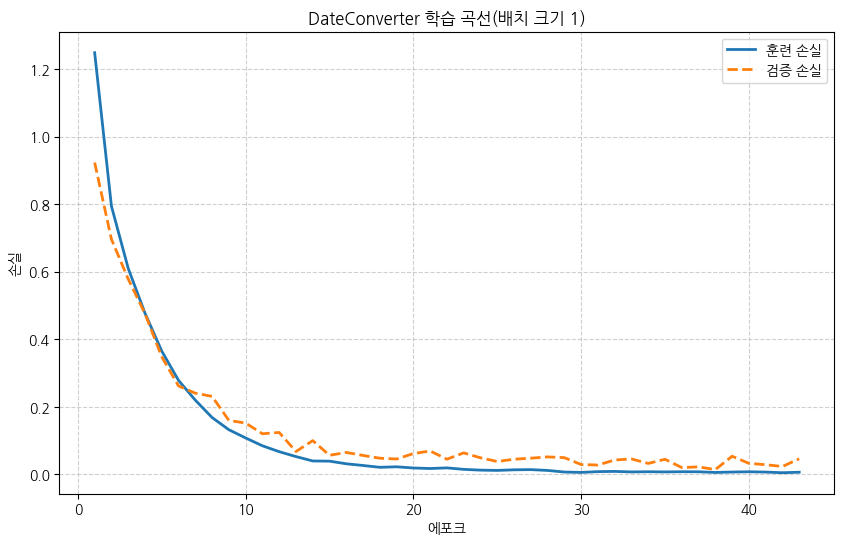

In [14]:
# 참고 - 학습 곡선
log.plot(title='DateConverter 학습 곡선(배치 크기 1)')

## [코드 9-12] Seq2Seq 모델의 예측(생성) 함수

학습용 `forward()`는 교사 강제를 쓰므로 생성에 쓸 수 없다. 예측 함수는
`<sos>`로 시작해 이전 생성 토큰을 다음 마중물로 사용하며, `<eos>`가 나오거나
`max_length`에 도달할 때까지 토큰을 하나씩 생성한다.

In [15]:
########################################################################################
# 코드 9-11 - Seq2Seq 모델의 예측(생성) 함수
########################################################################################

# 입력 날짜 문자열(src_text)을 출력 날짜 문자열로 변환하는 예측 함수
#   max_length: <eos> 토큰이 생성되지 않을 때를 대비한 생성 길이 제한 인자
@torch.no_grad()
def predict(model, src_text, src_vocab, tgt_vocab, device=None, max_length=12):
    if device is None: device = torch.device('cpu')
    model.eval()
    decoder = model.decoder
    # 입력 문자열 -> 고유 번호 텐서(unsqueeze(0)로 배치 차원 추가)
    src_ids = src_vocab.encode(src_text)
    src = torch.tensor(src_ids).long().unsqueeze(0)             # 인코더 입력 텐서    
    src = src.to(device)
    # 인코더: 콘텍스트 벡터와 인코더의 상태 계산
    hidden, cell = model.encoder(src)                           # 인코더의 상태
    context = hidden[-1].unsqueeze(1)                           # 콘텍스트 벡터
    # 디코더 첫 입력 토큰: <sos>를 사용(<sos>의 다음 토큰이 첫 번째 예측 토큰이 됨)
    tgt_token = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)      
    result_ids = []
    # <eos>가 생성될 때 까지 또는 최대 max_length회 forward_step() 반복 호출
    for _ in range(max_length):
        # 다음 토큰 하나 예측(디코더의 forward_step() 메서드 호출)
        logits, hidden, cell = decoder.forward_step(tgt_token, hidden, cell, context)
        pred = logits.argmax(dim=-1, keepdim=True)              # 최대 로짓 토큰
        if pred.item() == EOS_IDX:                              # <eos> 생성 시 종료
            break
        result_ids.append(pred.item())
        # 다음 마중물 토큰: 예측 시에는 교사 강제 없이 생성 토큰 사용
        tgt_token = pred                            
    return ''.join(tgt_vocab.decode(result_ids))


In [16]:
# 참고 - 변환 결과 출력

# show_sample_result(): 샘플 하나의 변환 결과를 출력 형태로 정리하는 헬퍼 함수
def show_sample_result(src_text, tgt_text, predicted_text):
    mark = '정답' if predicted_text == tgt_text else '오답'
    return f'  {src_text:<40s} => {predicted_text} ({mark})'

# 임의의 날짜 하나를 선택해 여덟 종류의 입력 형식으로 테스트 데이터쌍 생성
test_date = choice_random_dates(1) * 8
test_src_dates, test_tgt_dates = generate_datepairs(test_date)
print(f'정답 날짜 문자열: {test_tgt_dates[0]}')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(test_src_dates, test_tgt_dates):
    predicted_text = predict(model, src_text, src_vocab, tgt_vocab, device)
    print(show_sample_result(src_text, tgt_text, predicted_text))

정답 날짜 문자열: 2034-1-14
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  14 January 2034                          => 2034-1-14 (정답)
  14 Jan 2034                              => 2034-1-14 (정답)
  January 14, 2034                         => 2034-1-14 (정답)
  Jan 14, 2034                             => 2034-1-14 (정답)
  01/14/2034                               => 2034-1-14 (정답)
  2034/01/14                               => 2034-1-14 (정답)
  14-01-2034                               => 2034-1-14 (정답)
  2034-01-14                               => 2034-1-14 (정답)


## 정리

- Seq2Seq 모델은 인코더 LSTM이 만든 콘텍스트 벡터 `hidden[-1]`을 좁은 통로로
  디코더 LSTM에 전달하는 구조다.
- 디코더는 매 시점 `forward_step()`으로 한 토큰씩 생성하며, 학습 단계에서는
  교사 강제 비율로 정답 토큰과 이전 생성 토큰을 섞어 사용한다.
- 배치 크기 1로 학습한 본문의 검증 정확도는 95.80%였다. 노트북도 같은 환경
  에서 유사한 정확도에 도달한다(시드/디바이스 차이로 변동 가능).
- 9-3절 어텐션 노트북에서 노이즈 데이터셋으로 비교 학습한다.

- 참고: 노이즈가 섞인 데이터로 모델을 학습하는 과정 및 결과는 9-2절 노트북에 포함됨

## 긴 입력에서 정보가 희석되는 정보 병목

9-3절 `data.ipynb`의 노이즈 데이터 생성법을 사용해, 입력 날짜 문자열 앞뒤에
무작위 문자를 덧붙인 최대 40자 입력으로 두 가지를 확인한다.

1. (참고) 깨끗한 데이터로 학습한 기존 모델에 노이즈 입력을 넣은 결과
2. 노이즈 데이터로 9-1절 모델을 재학습한 후의 변환 결과

In [ ]:
# 참고 - 노이즈 데이터 생성 함수(9-3절의 데이터 생성 함수와 동일)

import string

# 날짜 문자열 앞뒤에 무작위 길이의 무작위 노이즈를 덧붙인 문자열 생성
def add_random_noise(text, max_length=40):
    noise_chars = (
        string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    )
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix_length = random.randint(0, remaining)
        suffix = ''.join(random.choices(noise_chars, k=suffix_length))
    return prefix + text + suffix

# 노이즈가 추가된 날짜 문자열 쌍 생성 함수
def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(src_format)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


정답 날짜 문자열: 2014-9-25
기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  cyt25 September 20148}h                  => 변환 불가 (어휘 사전에 없는 문자 '}')
  ciu1X@!LNy]^o25 Sep 2014En/Dii=1)#V<H    => 변환 불가 (어휘 사전에 없는 문자 'X')
  A3{Grg6&>[]HO-oF7September 25, 2014,52p# => 변환 불가 (어휘 사전에 없는 문자 '{')
  Py:9tSep 25, 2014=*ucCxs,]C              => 변환 불가 (어휘 사전에 없는 문자 'P')
  S{5mm%V%MZG?mR^[no8109/25/2014H?V<[b     => 변환 불가 (어휘 사전에 없는 문자 '{')
  k{%&EAoa##<^Tj3-TrHo.:;2014/09/25RjG>)   => 변환 불가 (어휘 사전에 없는 문자 'k')
  f{.hRg^25-09-2014lQWx                    => 변환 불가 (어휘 사전에 없는 문자 'f')
  1/:^9@J7H|OwfbX0a!ffcDTyRV#2014-09-25vQK => 변환 불가 (어휘 사전에 없는 문자 ':')


In [ ]:

# # 참고 - 


# #  data.ipynb 본문 복사) + 기존 모델에 노이즈 입력
# # 9-3절에서 사용하는 노이즈 추가 함수. 날짜 문자열 앞뒤에 무작위 문자를 덧붙인다.






# # 깨끗한 날짜로 학습한 기존 model에 노이즈 입력을 넣어 본다.
# random.seed(SEED)
# test_date = choice_random_dates(1) * 8
# noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

# print(f'정답 날짜 문자열: {noisy_tgt[0]}')
# print('기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:')
# print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
# for src_text, tgt_text in zip(noisy_src, noisy_tgt):
#     try:
#         predicted_text = predict(model, src_text, src_vocab, tgt_vocab, device)
#         print(show_sample_result(src_text, tgt_text, predicted_text))
#     except KeyError as unknown_char:
#         # 노이즈 문자는 깨끗한 데이터로 만든 어휘 사전에 없어 인코딩 자체가 실패한다.
#         print(f'  {src_text:<40s} => 변환 불가 (어휘 사전에 없는 문자 {unknown_char})')

In [ ]:
raise NotImplementedError("This section is for demonstration purposes and should not be executed directly.")

# 참고 - DateConverter 모델을 노이즈 추가 데이터로 학습하고 결과 확인

# 노이즈 데이터셋 생성 (4,000쌍)
common.set_seed(SEED)  

date_list_noisy = choice_random_dates(4000)
src_dates_noisy, tgt_dates_noisy = generate_noisy_datepairs(date_list_noisy)
print('노이즈 데이터셋 예시:')
for i in range(2):
    print(f'  {src_dates_noisy[i]!r} -> {tgt_dates_noisy[i]!r}')

# 어휘 사전 생성(노이즈 포함)
src_vocab_noisy = Vocab(src_dates_noisy, special_tokens)
tgt_vocab_noisy = Vocab(tgt_dates_noisy, special_tokens)
print(f'입력 어휘 사전 크기: {len(src_vocab_noisy)}')
print(f'출력 어휘 사전 크기: {len(tgt_vocab_noisy)}')

# 데이터셋과 데이터로더 생성
train_set_noisy = DateDataset(
    src_dates_noisy[:3000], tgt_dates_noisy[:3000], src_vocab_noisy, tgt_vocab_noisy)
valid_set_noisy = DateDataset(
    src_dates_noisy[3000:], tgt_dates_noisy[3000:], src_vocab_noisy, tgt_vocab_noisy)
train_loader_noisy = DataLoader(train_set_noisy, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_noisy = DataLoader(valid_set_noisy, batch_size=BATCH_SIZE, shuffle=False)

# 모델 생성 및 학습
encoder_noisy = Encoder(len(src_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder_noisy = Decoder(len(tgt_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
model_noisy = DateConverter(encoder_noisy, decoder_noisy).to(device)

optimizer_noisy = optim.Adam(model_noisy.parameters(), lr=LR)
history_noisy = train_with_early_stopping(
    model_noisy, train_loader_noisy, valid_loader_noisy, criterion, optimizer_noisy,
    epochs=EPOCHS, patience=PATIENCE, device=device
)

# 5) 변환 결과 - 노이즈 없는 입력과 노이즈 추가 입력 비교 (같은 날짜)
random.seed(SEED)
test_date = choice_random_dates(1) * 8
clean_src, clean_tgt = generate_datepairs(test_date)
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'\n정답 날짜 문자열: {clean_tgt[0]}')
print('노이즈 없는 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(clean_src, clean_tgt):
    predicted_text = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, predicted_text))

print('\n노이즈를 추가한 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    predicted_text = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, predicted_text))

노이즈 데이터셋 예시:
  'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'
  ']qDOx[U4120E=2_!A2hlkBq9T24 Dec 19191ZL' -> '1919-12-24'
입력 어휘 사전 크기: 42 -> 92
epoch    훈련 손실    검증 손실    정확도(%)     시간
 1/60       1.4026       1.1923        0.00%     0:34
 2/60       1.1129       1.0519        0.30%     1:08
 3/60       0.9858       0.9390        0.20%     1:41
 4/60       0.8564       0.8243        0.40%     2:13
 5/60       0.7449       0.7149        2.00%     2:44
 6/60       0.6480       0.6293        2.30%     3:16
 7/60       0.5725       0.5580        3.80%     3:48
 8/60       0.5030       0.4880        7.40%     4:20
 9/60       0.4505       0.4872        9.60%     4:52
10/60       0.4048       0.4252       13.80%     5:24
11/60       0.3625       0.3980       20.50%     5:56
12/60       0.3166       0.3468       22.80%     6:28
13/60       0.2800       0.3340       29.20%     7:00
14/60       0.2550       0.3057       37.00%     7:33
15/60       0.2313       0.2893       37.80%     8:12
16

In [ ]:
raise NotImplementedError("This section is for demonstration purposes and should not be executed directly.")


# 깨끗한 날짜로 학습한 기존 model에 노이즈 입력을 넣어 본다.
random.seed(SEED)
test_date = choice_random_dates(1) * 8
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'정답 날짜 문자열: {noisy_tgt[0]}')
print('기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    try:
        predicted_text = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
        print(show_sample_result(src_text, tgt_text, predicted_text))
    except KeyError as unknown_char:
        # 노이즈 문자는 깨끗한 데이터로 만든 어휘 사전에 없어 인코딩 자체가 실패한다.
        print(f'  {src_text:<40s} => 변환 불가 (어휘 사전에 없는 문자 {unknown_char})')

정답 날짜 문자열: 2014-9-25
기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  cyt25 September 20148}h                  => 2014-9-25 (정답)
  ciu1X@!LNy]^o25 Sep 2014En/Dii=1)#V<H    => 2014-9-25 (정답)
  A3{Grg6&>[]HO-oF7September 25, 2014,52p# => 2014-9-25 (정답)
  Py:9tSep 25, 2014=*ucCxs,]C              => 2014-9-25 (정답)
  S{5mm%V%MZG?mR^[no8109/25/2014H?V<[b     => 2014-9-24 (오답)
  k{%&EAoa##<^Tj3-TrHo.:;2014/09/25RjG>)   => 2014-9-25 (정답)
  f{.hRg^25-09-2014lQWx                    => 2014-9-25 (정답)
  1/:^9@J7H|OwfbX0a!ffcDTyRV#2014-09-25vQK => 2014-4-25 (오답)
